# Algorytm probabilistyczny Monte Carlo 
### Wyznaczenie przybliżonej wartosci liczby $\pi$
---
Opracowanie: `Kajetan Kowalski 421071`, IAD III rok, grupa ćwiczeniowa 1.

### 1. Wczytanie bibliotek

In [1]:
import numpy as np 
import pandas as pd 
import math
import random
import time
import matplotlib.pyplot as plt

### 2. Definicje generatorów liczb pseudolosowych

Do przeprowadzenia badania zastosowano kilka poznanych na wykładzie metod generowania ciągów liczb pseudolosowych, oraz zestawiono je z zaimplementowaną w standardową bibliotekę Python'a funkcję `random.random()`.

**2.1. Generator `random` z biblioteki Python'a**

In [2]:
def LibGenerator():
    return random.random()

Powyższa funkcja `LibGenerator()` bazuje na funkcji wbudowanej w standardowej bibliotece stosowanego w projekcie języka progamowania Python. Korzysta ona z algorytmu **Mersenne Twister**, czyli w teterministyczny sposób na podstawie ustalonego seed'a wyznacza kolejne wartości pseudolosowe. Algorytm ten opiera się na generowaniu kolejnych "losowych" wartości na podstawie wewnętrtrznego stanu generatora, a nie na podstawie wzoru rekurencyjnego. Końcowy wynik poddawany jest dodatkowo modyfikacjom bitowym.

**2.2. Generator Liniowy o maksymalnym okresie**

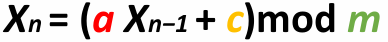

In [3]:
def LineGenerator(x, a, c, M):
    x = (a  * x + c) % M
    return x, x/M

Generator liniowy o maksymaslnym okresie, jest odmianą liniowych generatorów dających większą okresowość, wpływając na poprawienie się własności statystycznych generatora. 
- `x` - bieżący stan generatora,
- `a` - mnożnik, określa jak silna jest zależność sąsiednich wartości ciągu,
- `c` - przytrost, stała dodawana po mnożeniu - przesuwa wynik unikajac niekorzystnych powtórzeń,
- `M` - moduł ograniczający zakres wartości.

Wyniki zostały znoramlizowane do przedziału <0;1) poprzez podzielenie `x/M`.

**2.3. Generator afiniczny**

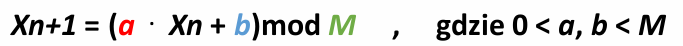

In [4]:
def AffineGenerator(x, a, b, M):
    x = (a * x + b) % M
    return x, x/M

Generator afiniczny jest zmodyfikowanym geneatorem liniowym. Posiada on zabespieczenie w postaci parametru `b`, który zapobiega wczesnemu zapętlaniu się ciągu.

- `x` - bieżący stan generatora,
- `a` - mnożnik, określa jak silna jest zależność sąsiednich wartości ciągu,
- `b` - przesunięcie, stała dodawana po mnożeniu - przesuwa wynik unikajac niekorzystnych powtórzeń,
- `M` - moduł ograniczający zakres wartości.

Wyniki zostały znoramlizowane do przedziału <0;1) poprzez podzielenie `x/M`.

**2.4. Generator wielomianowy**

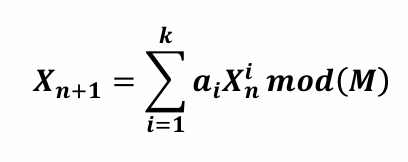

In [5]:
def PolynomialGenerator(x, a, M):
    s = 0
    for i in range(len(a)):
        s += a[i] * (x**(i+1))
    x = s % M
    
    return x, x/M

Generator wielomianowy ma na celu odejście od prostych lub lekko modyfikowanych zależności liniowych. Dzięki zastosowaniu wielomianowej postaci, przewidywalność generatora spada oraz uzyskujemy bardziej złożony sposób wyznaczania kolejnych wartości. Skutkiem tego jest ograniczenie regularności ciągu i utrudnienie zależności między kolejnymi elementami składowymi. 
- `x` - bieżący stan generatora,
- `a` - tablica współczynników wielomianu,
- `M` - moduł ograniczający zakres wartości.

Wyniki zostały znoramlizowane do przedziału <0;1) poprzez podzielenie `x/M`.

**2.5. Generator inwersyjny**

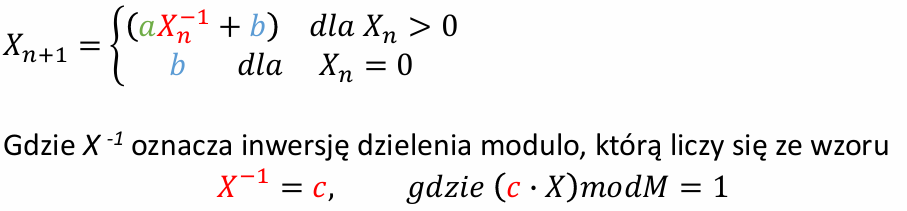

In [6]:
def InvGenerator(x, a, b, M):
    if x == 0: return b
    else:
        inv = pow(x, -1, M)
        x = (a * inv + b)%M
    
    return x, x/M

Algorytmy inwersyjne pojawiły się aby wsteczne odtworzenie algorytmu na podstawie ciągu wyjściowego było znacznie utrudnione. Stosowane są takie przekształcenia, które generują ciąg nie cechujący się lokalną liniowością. 
- `x` - bieżący stan generatora, 
- `a` - mnożnik,
- `b` - przesunięcie,
- `M` - moduł ograniczający zakres wartości (liczba pierwsza).

Wyniki zostały znoramlizowane do przedziału <0;1) poprzez podzielenie `x/M`.

### 3. Wyznaczenie przybliżonej wartości liczby $\pi$.

**3.1. Definicje zmiennych**

In [7]:
max_N = 1000000 # maksymalna liczba losowanych punktów
N_plot_values = [100, 1000, 10000, 1000000] # wybrane wartosci N dla wykresów
save_N = set(N_plot_values) # zbiór N do tabelki
num_series = 10 # liczba ścieżek (seed'ów) do wariancji
N_box_values = [100, 1000, 10000, 100000, 200000, 300000, 400000, 500000, 1000000] # wartosci dla boxplotów
N_labels = ["10^2", "10^3", "0.1", "1", "2", "3", "4", "5", "10"]
M = 2147483647 # 2^31 - 1 Park, Miller (1980)
a = 1664525 # mnożnik dla generatora liniowego, afinicznego i inwersyjnego Park, Miller (1980)
c = 1013904223
b = 1013904223 # c i b wartosci przesuniecia 
poly_a = [42, 10, 71] # wspolczynniki wielomianu generatora 

**3.2. Definicja funkcji losującej punkty**

In [8]:
generators = ["lib", "linear", "affine", "poly", "inv"]
sim_data = {}
results = []
N_range = np.arange(1, max_N + 1)

In [9]:
def generate_points(gen_type, n_points, seed=1):
    xs = np.zeros(n_points)
    ys = np.zeros(n_points)
    state_x = seed 
    
    if gen_type == "lib":
        random.seed(seed)
        
    for i in range(n_points):
        if gen_type == "lib":
            x, y = LibGenerator(), LibGenerator()
        elif gen_type == "linear":
            state_x, x = LineGenerator(state_x, a, c, M)
            state_x, y = LineGenerator(state_x, a, c, M)
        elif gen_type == "affine":
            state_x, x = AffineGenerator(state_x, a, b, M)
            state_x, y = AffineGenerator(state_x, a, b, M)
        elif gen_type == "poly":
            state_x, x = PolynomialGenerator(state_x, poly_a, M)
            state_x, y = PolynomialGenerator(state_x, poly_a, M)
        elif gen_type == "inv":
            state_x, x = InvGenerator(state_x, a, b, M)
            state_x, y = InvGenerator(state_x, a, b, M)
            
        xs[i] = x
        ys[i] = y
        
    return xs, ys

funkcja `generate_points` odpowiada za generowanie pseudolosowych punktów (x, y) z użyciem wskazanego jednego z wcześniej zdefiniowanych generatorów. 
- `gen_type` - generator, który ma zostać użyty
- `n_points` - liczba ile punktów ma zostać wylosowanych
- `seed` - ziarno losowe (stan startowy)

Na wyjsciu otrzymuje się tablicę zawierajaca "wylosowane" współrzędne punktów

**3.3. Obliczanie wartości PI za pomocą algorytmu Monte Carlo**

In [10]:
box_data = {gen: {n: [] for n in N_box_values} for gen in generators}
traces = {gen: [] for gen in generators}
exec_time = {gen: 0.0 for gen in generators}
for gen in generators:
    for seria in range(1, num_series + 1):
        start_t = time.perf_counter()
        # generowanie punktów i weryfikacja trafień
        xs, ys = generate_points(gen, max_N, seed=seria)
        exec_time[gen] += (time.perf_counter() - start_t)
        hit = (xs**2 + ys**2) <= 1
        hits = np.cumsum(hit)
        traces[gen].append(4 * hits / N_range)
        
        if seria == 1:
            pi_values = 4 * hits / N_range
            
            sim_data[gen] = {
                "x": xs,
                "y": ys,
                "hit": hit,
                "pi_values": pi_values
            }
            
            for n in save_N:
                idx = n - 1
                results.append({
                    "Generator": gen, "N": n, "hit": hits[idx],
                    "Pi_est": pi_values[idx], "Error": abs(math.pi - pi_values[idx])
                })
                
        # dane dla boxplotow
        for n in N_box_values:
            pi_est = 4 * hits[n - 1] / n
            box_data[gen][n].append(pi_est)

Powyższy blok kodu stanowi esencję działań projektu, gdzie skupiane są wszystkie obliczenia przetwarzające dane i doprowadzające do wyznaczenia wartosci $\pi$.
Analizując kod początkowo tworzone są słowniki `box_data` oraz `traces`, któe służą do przechowywania wyników. Następnie iterując po każdym z generatorów dziesięciokrotnie, przy zmianie warunków początkowych (seed), losuje się różne zestawy punktów, służących do estymacji $\pi$. W każdym kroku generowany jest milion punktów, które są poddawane weryfikacji czy znalazły się w obrębie ćwiartki koła o promieniu 1 (zmienna boolowska `hit`). 
Kolejnym kluczowym krokiem jest zapisanie danych wykorzystywanych do wizualiuzacji, takie jak współrzędne punktów, czy przewidywane wartosci pi (`pi_values`). 

**3.4. Zestawienie wyników estymacji**

In [11]:
final_results = []

for gen in generators:
    for n in save_N:
        i = n - 1
        pi_s1 = sim_data[gen]["pi_values"][i]
        err_s1 = abs(math.pi - pi_s1)
        estimates_10 = box_data[gen][n]
        avg_pi_10 = np.mean(estimates_10)
        avg_err_10 = abs(math.pi - avg_pi_10)
        
        final_results.append({
            "Metoda": gen,
            "N losowań": n,
            "Pi (Seria 1)": pi_s1,
            "Błąd (Seria 1)": err_s1,
            "Średnie Pi (10 serii)": avg_pi_10,
            "Średni Błąd (10 serii)": avg_err_10
        })

df_final = pd.DataFrame(final_results)

df_final.sort_values(by=["Metoda", "N losowań"], inplace=True)

cols_to_format = ["Pi (Seria 1)", "Błąd (Seria 1)", "Średnie Pi (10 serii)", "Średni Błąd (10 serii)"]
for col in cols_to_format:
    df_final[col] = df_final[col].map(lambda x: f"{x:.6f}")

display(df_final.reset_index(drop=True))

,Metoda,N losowań,Pi (Seria 1),Błąd (Seria 1),Średnie Pi (10 serii),Średni Błąd (10 serii)
0,affine,100,3.160000,0.018407,3.224000,0.082407
1,affine,1000,3.216000,0.074407,3.178800,0.037207
2,affine,10000,3.152800,0.011207,3.142120,0.000527
3,affine,1000000,3.145052,0.003459,3.141784,0.000191
4,inv,100,2.960000,0.181593,3.144000,0.002407
5,inv,1000,3.148000,0.006407,3.164800,0.023207
6,inv,10000,3.129600,0.011993,3.140280,0.001313
7,inv,1000000,3.144916,0.003323,3.141073,0.000519
8,lib,100,3.200000,0.058407,3.088000,0.053593
9,lib,1000,3.112000,0.029593,3.133600,0.007993


Po wylosowaniu i wyznaczeniu wartosci PI, można w powyższej tabeli można przeglądnąć wyniki i ocenić ich jakość. Proces utworzenia tej tabeli polega na przeszukaniu struktur `sim_data` oraz `box_data` w celu pobrania z nich informacji o wartosci oraz odchyłkach. 

### 4. Wizualizacje

**4.1. Rozkład N losowych punktów na ćwiartce okręgu**

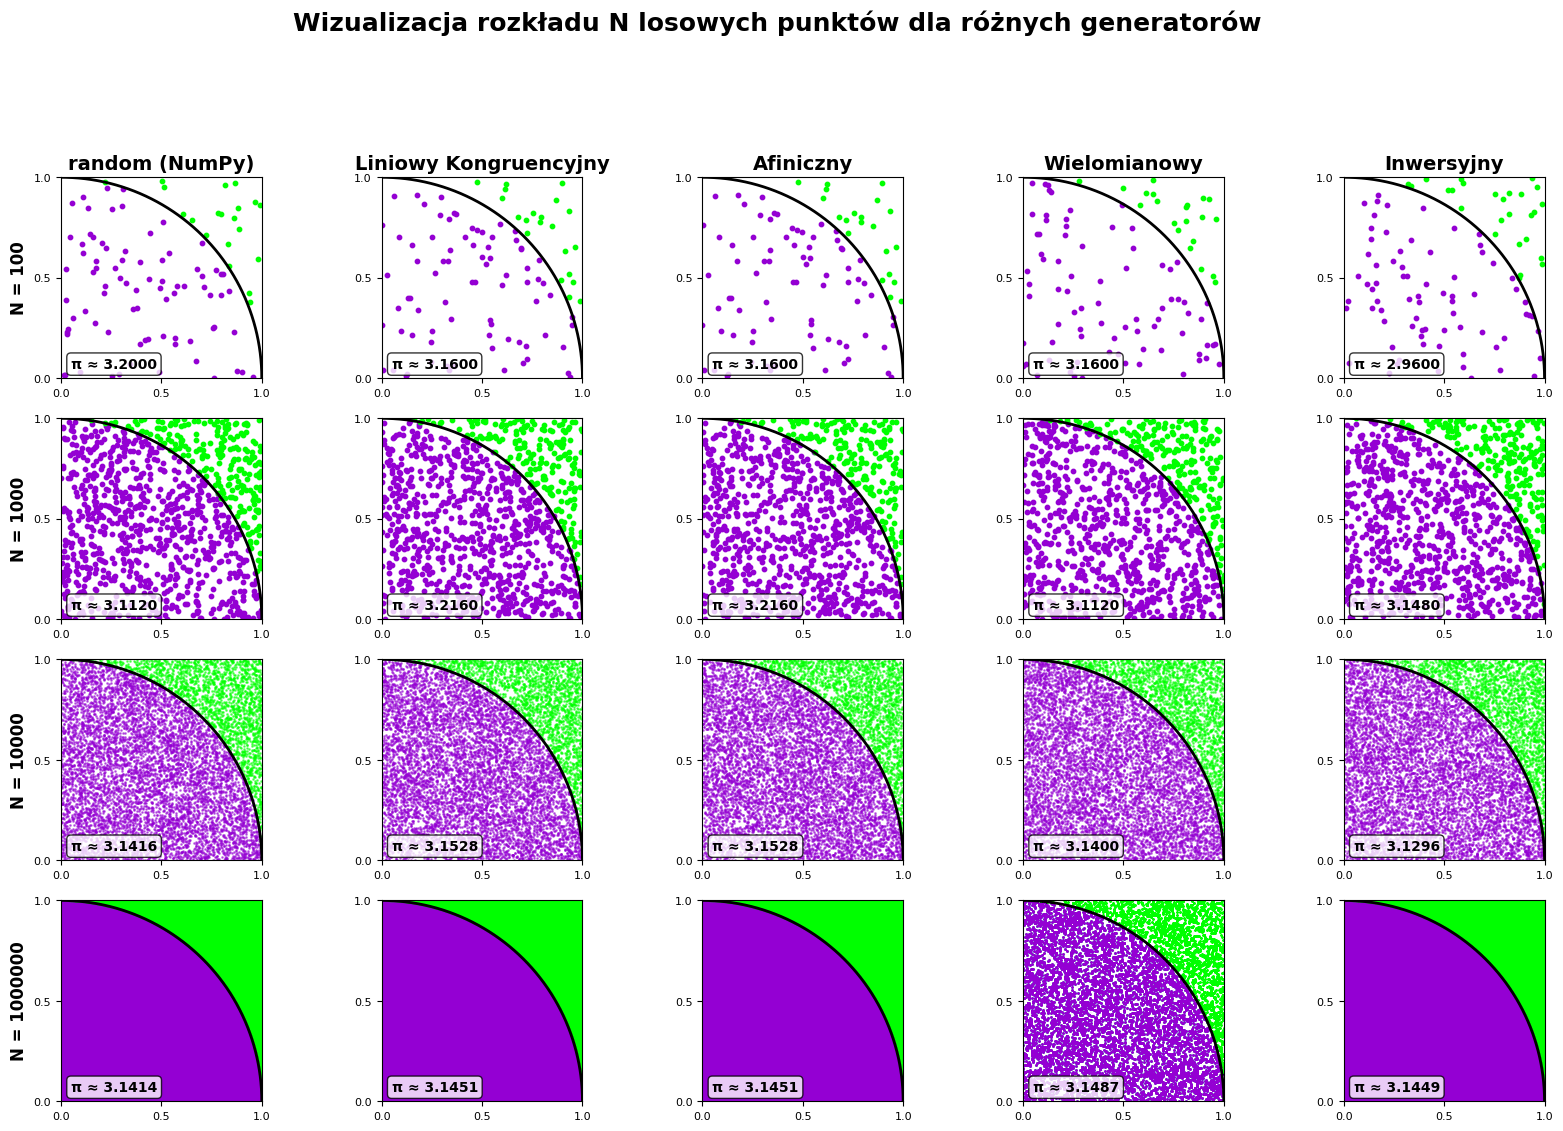

In [12]:
labels = {
    "lib": "random (NumPy)",
    "linear": "Liniowy Kongruencyjny",
    "affine": "Afiniczny",
    "poly": "Wielomianowy",
    "inv": "Inwersyjny"
    }

fig, axes = plt.subplots(4, 5, figsize=(20, 12))
theta = np.linspace(0, np.pi/2, 300)

for r, n_plot in enumerate(sorted(N_plot_values)):
    for c, gen in enumerate(generators):
        ax = axes[r, c]
        xs = sim_data[gen]["x"][:n_plot]
        ys = sim_data[gen]["y"][:n_plot]
        ins = sim_data[gen]["hit"][:n_plot]
        
        xs_hit, ys_hit = xs[ins], ys[ins]
        xs_out, ys_out = xs[~ins], ys[~ins]
        
        pt_size = 10 if n_plot <= 1000 else (1 if n_plot <= 10000 else 0.1)
        alpha_val = 1.0 if n_plot <= 1000 else (0.5 if n_plot <= 10000 else 0.1)
        
        ax.scatter(xs_hit, ys_hit, s=pt_size, color="darkviolet", alpha=alpha_val)
        ax.scatter(xs_out, ys_out, s=pt_size, color="lime", alpha=alpha_val)
        ax.plot(np.cos(theta), np.sin(theta), color="black", linewidth=2)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal")
        ax.set_xticks([0, 0.5, 1])
        ax.set_yticks([0, 0.5, 1])
        ax.tick_params(labelsize=8)

        pi_est = 4 * ins.sum() / n_plot 
        bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8)
        ax.text(0.05, 0.05, f"\u03C0 ≈ {pi_est:.4f}", transform=ax.transAxes,
            fontsize=10, fontweight='bold', bbox=bbox_props)

        if r == 0:
            ax.set_title(labels[gen], fontsize=14, fontweight='bold')
        if c == 0:
            ax.set_ylabel(f"N = {n_plot}", fontsize=12, fontweight='bold')

plt.suptitle("Wizualizacja rozkładu N losowych punktów dla różnych generatorów", 
             fontsize=18, fontweight='bold', y=1.02)

plt.show()

**4.2. Zbiezność estymacji do liczby $\pi$ dla jednego przebiegu.**

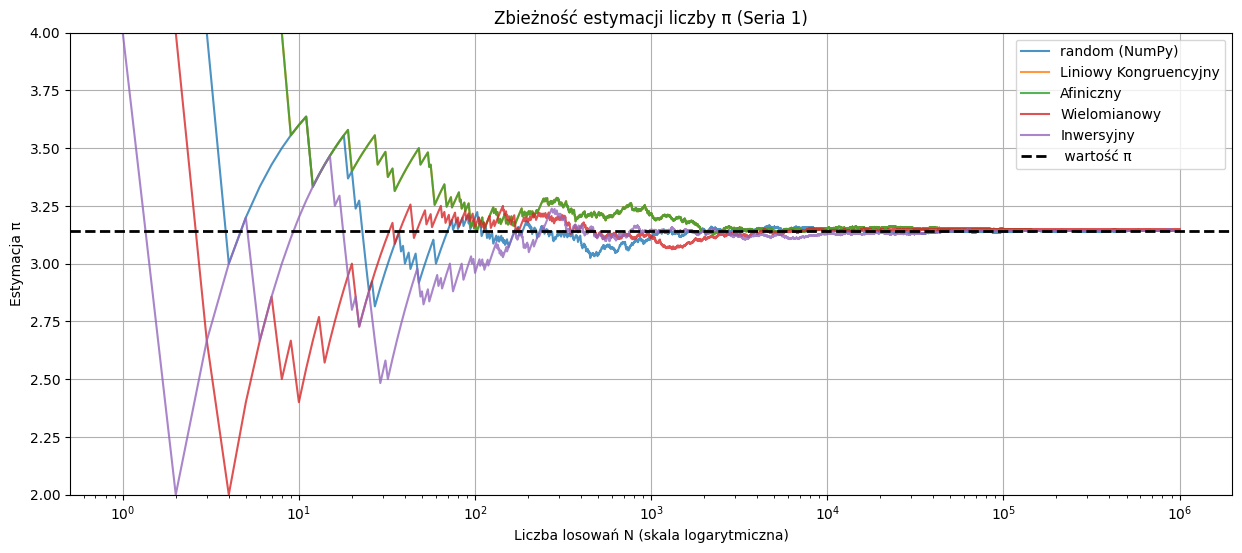

In [13]:
plt.figure(figsize=(15, 6))
for gen in generators:
    plt.plot(N_range, sim_data[gen]["pi_values"], label=labels[gen], alpha=0.8)

plt.axhline(np.pi, linestyle="--", color="black", label=" wartość \u03C0", linewidth=2)
plt.xscale('log')
plt.ylim(2.0, 4.0)
plt.xlabel("Liczba losowań N (skala logarytmiczna)")
plt.ylabel("Estymacja \u03C0")
plt.title("Zbieżność estymacji liczby \u03C0 (Seria 1)")
plt.legend()
plt.grid(True)
plt.show()

**4.3. Zbiezność estymacji do liczby $\pi$ dla 10 niezależnych.**

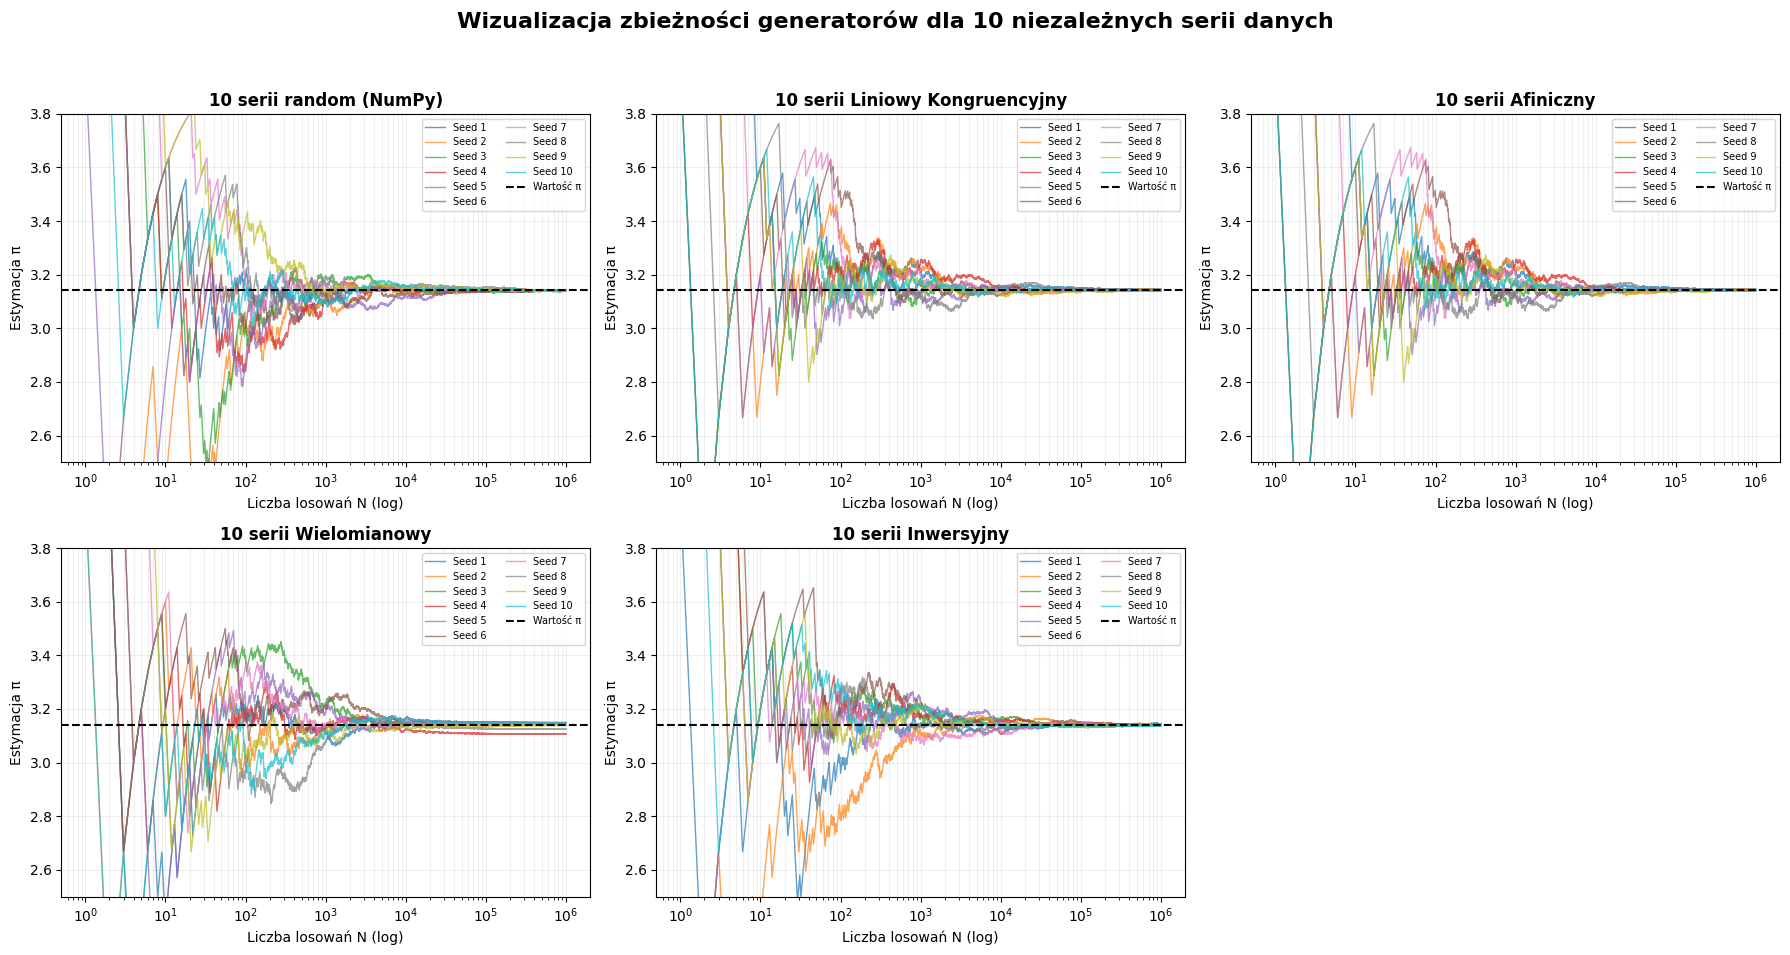

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, gen in enumerate(generators):
    ax = axes[i]
    for s_idx, path in enumerate(traces[gen]):
        ax.plot(N_range, path, linewidth=1.0, label=f"Seed {s_idx + 1}", alpha=0.7)
    
    ax.axhline(np.pi, color="black", linestyle="--", linewidth=1.5, label="Wartość \u03C0")
    ax.set_xscale('log')
    ax.set_ylim(2.5, 3.8)
    ax.set_title(f"10 serii {labels[gen]}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Liczba losowań N (log)")
    ax.set_ylabel("Estymacja \u03C0")
    ax.grid(True, which="both", ls="-", alpha=0.2)
    ax.legend(prop={'size': 7}, loc='upper right', ncol=2)
axes[5].axis('off')
plt.suptitle("Wizualizacja zbieżności generatorów dla 10 niezależnych serii danych", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**4.4. Analiza spadku błędu w zależności od liczby losowań N.**

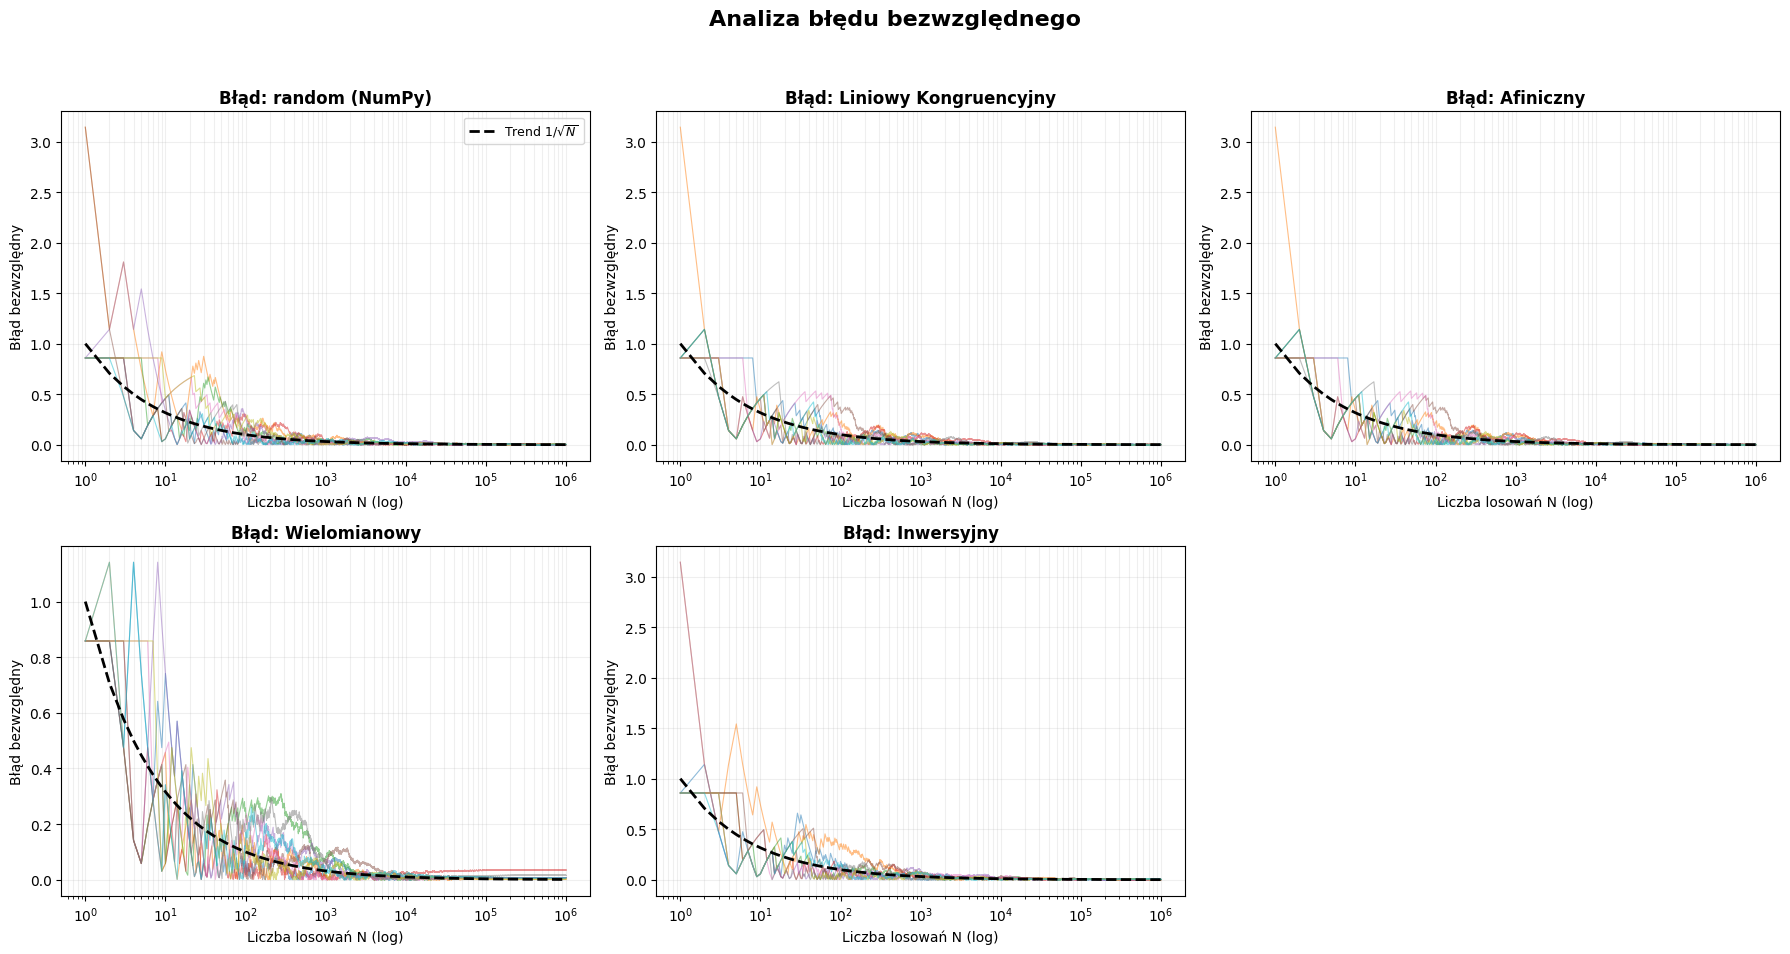

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, gen in enumerate(generators):
    ax = axes[i]
    for s_idx, path in enumerate(traces[gen]):
        errors = np.abs(np.array(path) - np.pi)
        ax.plot(N_range, errors, linewidth=0.8, alpha=0.5)
    
    theoretical_slope = 1.0 / np.sqrt(N_range)
    ax.plot(N_range, theoretical_slope, color="black", linestyle="--", 
            linewidth=2, label=r"Trend $1/\sqrt{N}$")
    
    ax.set_xscale('log')
    
    ax.set_title(f"Błąd: {labels[gen]}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Liczba losowań N (log)")
    ax.set_ylabel("Błąd bezwzględny")
    ax.grid(True, which="both", ls="-", alpha=0.2)
    
    if i == 0:
        ax.legend(prop={'size': 9}, loc='upper right')

axes[5].axis('off')

plt.suptitle("Analiza błędu bezwzględnego", 
             fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**4.5. Rozrzut estymacji w 10 seriach dla różnych badanych generatorów.**

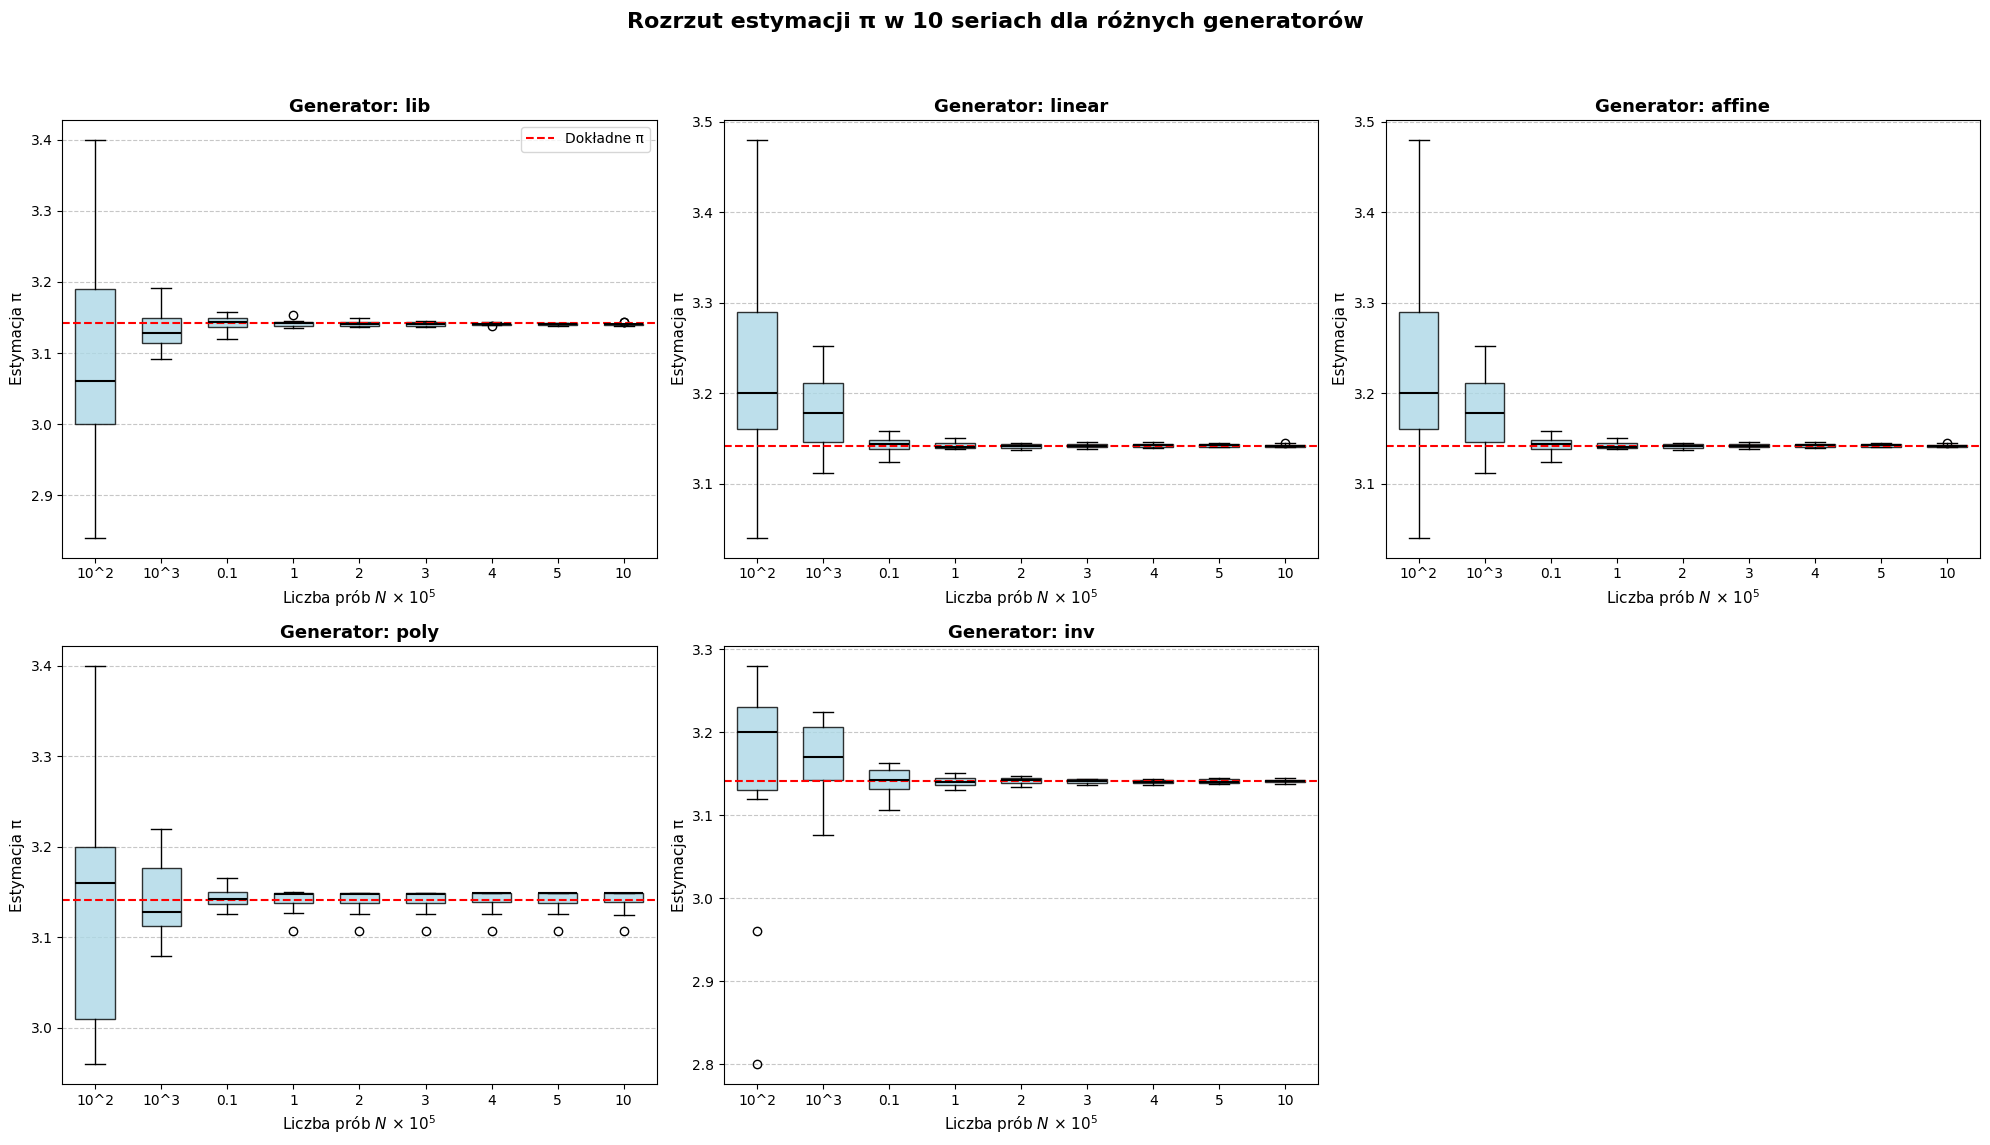

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, gen in enumerate(generators):
    ax = axes[i]
    data_to_plot = [box_data[gen][n] for n in N_box_values]
    
    bp = ax.boxplot(data_to_plot, tick_labels=N_labels, patch_artist=True, widths=0.6)
    
    for box in bp['boxes']:
        box.set_facecolor('lightblue')
        box.set_alpha(0.8)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(1.5)
        
    ax.axhline(np.pi, color="red", linestyle="--", linewidth=1.5, label="Dokładne \u03C0")
    ax.set_title(f"Generator: {gen}", fontsize=13, fontweight='bold')
    ax.set_xlabel(f"Liczba prób $N$ × $10^5$", fontsize=11)
    ax.set_ylabel("Estymacja \u03C0", fontsize=11)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    
    if i == 0: 
        ax.legend(loc='upper right')

axes[5].axis('off')
plt.suptitle("Rozrzut estymacji \u03C0 w 10 seriach dla różnych generatorów", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()

**4.6. Analiza wydajnosci - czas wykonania 10 serii w zaleznosci od obranego generatora.**

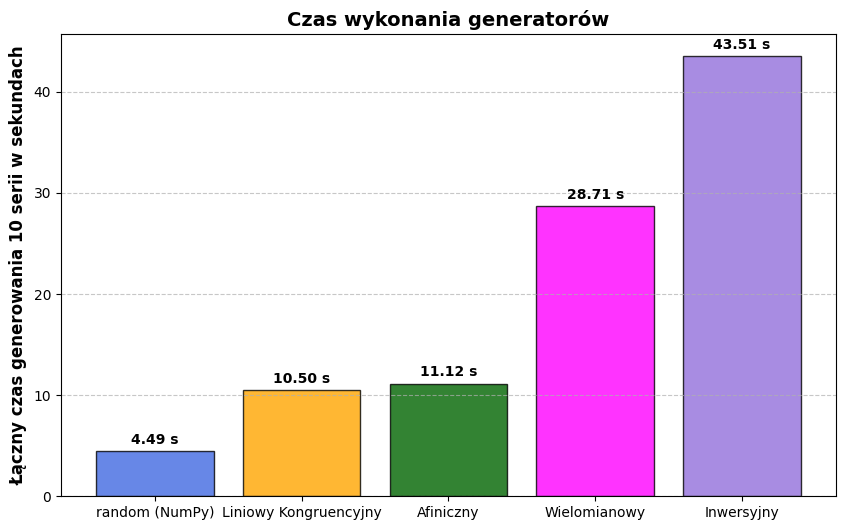

In [17]:
names = [labels[gen] for gen in generators]
times = [exec_time[gen] for gen in generators]

colors = ['royalblue', 'orange', 'darkgreen', 'magenta', 'mediumpurple']

plt.figure(figsize=(10, 6))
bars = plt.bar(names, times, color=colors, edgecolor='black', alpha=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(times)*0.01), 
             f"{yval:.2f} s", ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.ylabel("Łączny czas generowania 10 serii w sekundach", fontsize=12, fontweight='bold')
plt.title("Czas wykonania generatorów", fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()